# CS634 Final Project 

## Naveen Kumar Kovi - nk758

### Diabetes Classification (Random Forest, SVM, LSTM)

The goal of this project is to build and compare different classification models to predict whether a patient has diabetes based on clinical features from the Pima Indians Diabetes Dataset.

- **Random Forest** (ensemble tree-based model),
- **Support Vector Machine (SVM)** with linear kernel (classic ML baseline),
- **LSTM** (a simple deep learning model applied to tabular data).

The evaluation is based on **10-fold stratified cross-validation** and several performance metrics, including Accuracy, Precision, Recall, F1-score, ROC–AUC, Brier Score, Brier Skill Score, TSS, and HSS.


In [204]:
# Importing Libraries and Setting Up Environment 

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import is_numeric_dtype

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    brier_score_loss,
    roc_curve,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input
from tensorflow.keras.optimizers import Adam

%matplotlib inline

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
tf.get_logger().setLevel("ERROR")
warnings.filterwarnings("ignore", category=UserWarning, module="keras")


### Loading the Diabetes Dataset


In [205]:
# Loading the Diabetes Dataset

data_path = "../data/diabetes.csv"

df = pd.read_csv(data_path)
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Dataset Overview (Shape, Columns, Class Counts, Statistics)


In [207]:
# Here I test the dataset structure, basic statistics, and the distribution of the target variable **Outcome**.

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

print("\nClass distribution (Outcome):")
print(df["Outcome"].value_counts())

df.describe()


Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Class distribution (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Checking for Data Imbalance

The Outcome variable is binary (0 = non-diabetic, 1 = diabetic).  
Here I compute the counts and percentages of each class to see if the data is imbalanced.

In [208]:
# Checking for Data Imbalance

print("--Checking for Data Imbalance--\n")

# Count occurrences
positive = df['Outcome'].value_counts()[1]
negative = df['Outcome'].value_counts()[0]

pos_percent = (positive / len(df)) * 100
neg_percent = (negative / len(df)) * 100

print(f"Number of Positive Outcomes:  {positive}")
print(f"Percentage of Positive Outcomes: {pos_percent:.1f}%\n")

print(f"Number of Negative Outcomes:  {negative}")
print(f"Percentage of Negative Outcomes: {neg_percent:.1f}%")


--Checking for Data Imbalance--

Number of Positive Outcomes:  268
Percentage of Positive Outcomes: 34.9%

Number of Negative Outcomes:  500
Percentage of Negative Outcomes: 65.1%


### Exploratory Data Analysis (Histograms and Correlation Heatmap)

Next, I visualize the distributions of each feature and the correlation structure of the dataset.

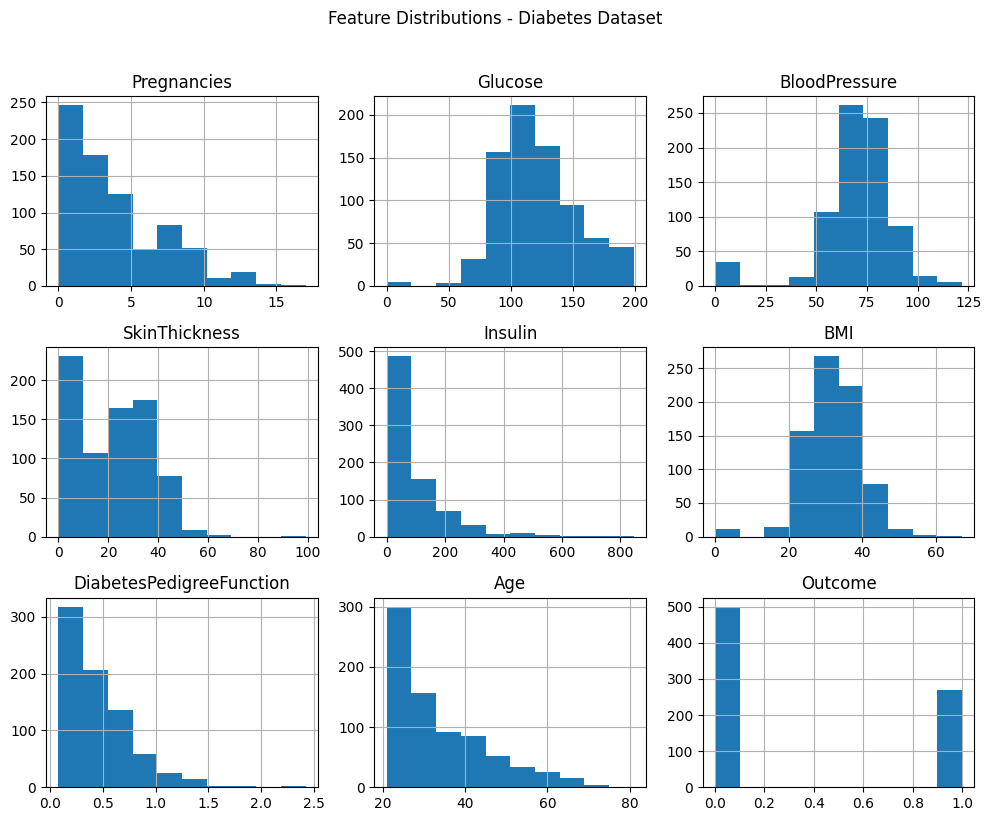

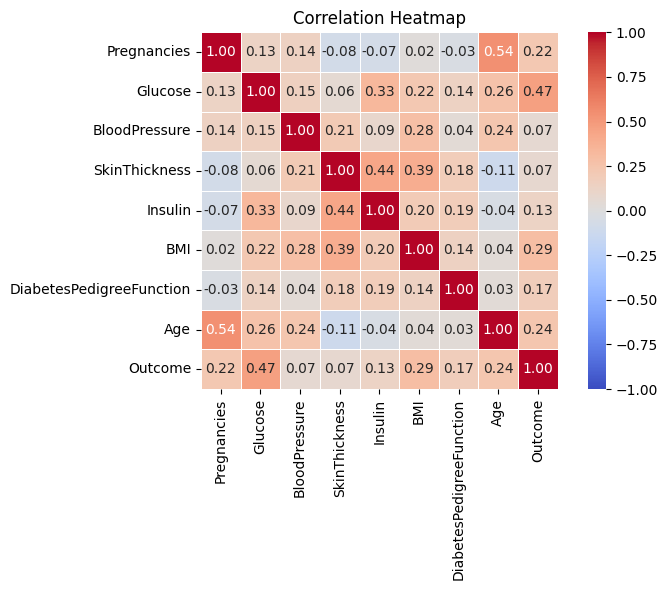

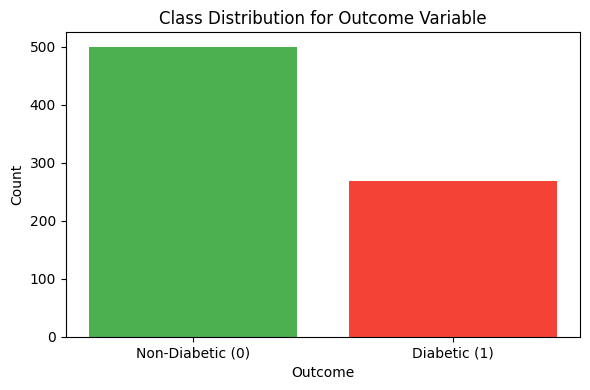

In [209]:
# Feature Distributions

# Histograms
df.hist(figsize=(10, 8))
plt.suptitle("Feature Distributions - Diabetes Dataset", y=1.02)
plt.tight_layout()
plt.show()

# Heatmaps
plt.figure(figsize=(8, 6))

corr = df.corr()  

sns.heatmap(
    corr,annot=True,fmt=".2f",cmap="coolwarm",vmin=-1, vmax=1,linewidths=0.5, square=True        
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Class Imbalance Bar Plot
plt.figure(figsize=(6,4))

counts = df['Outcome'].value_counts().sort_index().values
labels = ['Non-Diabetic (0)', 'Diabetic (1)']
colors = ["#4CAF50", "#F44336"]

plt.bar(labels, counts, color=colors)

plt.title("Class Distribution for Outcome Variable")
plt.ylabel("Count")
plt.xlabel("Outcome")
plt.tight_layout()
plt.show()



### Data Preprocessing


In [210]:
# Preprocess_data

# Feature Processing and Standardization Function 

def preprocess_data(df: pd.DataFrame, label_col: str = "Outcome"):
    
    if label_col not in df.columns:
        raise ValueError(f"Label column '{label_col}' not found.")

    y_raw = df[label_col]

    if not is_numeric_dtype(y_raw):
        uniques = list(y_raw.unique())
        if len(uniques) != 2:
            raise ValueError("Label must be binary.")
        mapping = {uniques[0]: 0, uniques[1]: 1}
        y = y_raw.map(mapping).astype(int).values
    else:
        uniq = sorted(y_raw.unique())
        if len(uniq) != 2:
            raise ValueError("Label must be binary.")
        y = y_raw.astype(int).values

    X = df.drop(columns=[label_col])
    X = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).copy()

    X = X.fillna(X.median())

    X_std = (X - X.mean()) / X.std(ddof=0)
    X_std = X_std.fillna(0.0)

    feature_names = list(X_std.columns)
    return X_std.values, y, feature_names

# Applying Preprocessing to Dataset

X, y, feature_names = preprocess_data(df, "Outcome")
X.shape, len(y)


((768, 8), 768)

### LSTM Model Builder Function

Here I define a simple LSTM model that takes the feature vector as a short sequence of length equal to the number of features.

In [211]:
# LSTM Model Builder Function

def build_lstm(input_dim: int):
    model = Sequential()
    model.add(Input(shape=(input_dim, 1)))
    model.add(LSTM(32))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(learning_rate=0.001),
        metrics=["accuracy"],
    )
    return model


### (train_test_split)

In [212]:
# Splitting Data into Training & Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((614, 8), (154, 8))

### Initial Training of Random Forest, SVM, and LSTM

Using the train–test split, I train all three models and compute their AUC values as a quick comparison.

In [213]:
# Training RF, SVM, and LSTM Models

results = {}

# -- Random Forest --
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
results["Random Forest"] = auc_rf

# -- SVM --
svm = SVC(kernel="linear", probability=True, random_state=42)
svm.fit(X_train, y_train)
y_prob_svm = svm.predict_proba(X_test)[:, 1]
auc_svm = roc_auc_score(y_test, y_prob_svm)
results["SVM (Linear)"] = auc_svm

# -- LSTM --
input_dim = X_train.shape[1]
X_train_seq = X_train.reshape((X_train.shape[0], input_dim, 1))
X_test_seq = X_test.reshape((X_test.shape[0], input_dim, 1))

lstm = build_lstm(input_dim)
lstm.fit(X_train_seq, y_train, epochs=15, batch_size=32, verbose=0)
y_prob_lstm = lstm.predict(X_test_seq, verbose=0).ravel()
auc_lstm = roc_auc_score(y_test, y_prob_lstm)
results["LSTM"] = auc_lstm

results


{'Random Forest': 0.8167592592592593,
 'SVM (Linear)': 0.8274999999999999,
 'LSTM': 0.7124074074074074}

### ROC Curve Comparison

The ROC curves show the trade-off between true positive rate and false positive rate for each model on the test set.

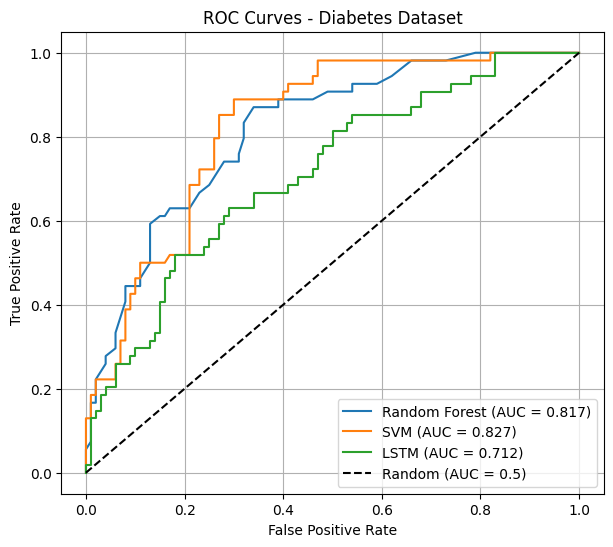

In [214]:
# Plotting ROC Curves for All Models

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_prob_lstm)

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC = {auc_lstm:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Diabetes Dataset")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


###  Metrics Computation Function for Cross-Validation

I implement a function that computes all custom metrics from the confusion matrix and predicted probabilities.

In [215]:
# Metrics Computation Function for Cross-Validation

def compute_metrics(cm, y_true, y_prob):

    (TP, FN), (FP, TN) = cm
    P = TP + FN
    N = TN + FP

    def safe_div(num, den):
        return num / den if den != 0 else 0.0

    TPR = safe_div(TP, P)          # sensitivity / recall
    TNR = safe_div(TN, N)          # specificity
    FPR = safe_div(FP, N)
    FNR = safe_div(FN, P)

    Precision = safe_div(TP, TP + FP)
    F1 = safe_div(2 * TP, 2 * TP + FP + FN)
    Accuracy = safe_div(TP + TN, P + N)
    Error_rate = 1.0 - Accuracy

    # Balanced accuracy
    BACC = (TPR + TNR) / 2.0

    # True Skill Statistic
    TSS = TPR - FPR

    # Heidke Skill Score
    HSS_num = 2 * (TP * TN - FP * FN)
    HSS_den = (P * (FN + TN) + (TP + FP) * N)
    HSS = safe_div(HSS_num, HSS_den)

    # Brier score
    bs = brier_score_loss(y_true, y_prob)

    # Brier skill score vs climatology
    y_bar = np.mean(y_true)
    bs_ref = np.mean((y_true - y_bar) ** 2)
    BSS = 1.0 - safe_div(bs, bs_ref) if bs_ref != 0 else 0.0

    # AUC
    try:
        AUC = roc_auc_score(y_true, y_prob)
    except ValueError:
        AUC = 0.0

    return {
        "TP": TP, "TN": TN, "FP": FP, "FN": FN,
        "P": P, "N": N,
        "TPR": TPR, "TNR": TNR, "FPR": FPR, "FNR": FNR,
        "Precision": Precision, "Recall": TPR, "F1": F1,
        "Accuracy": Accuracy, "Error_rate": Error_rate,
        "BACC": BACC, "TSS": TSS, "HSS": HSS,
        "BS": bs, "BSS": BSS, "AUC": AUC,
    }


### 10-Fold Stratified Cross-Validation for RF, SVM, and LSTM

I now run 10-fold stratified cross-validation over the full dataset and compute all metrics for each fold and each algorithm.

In [216]:
# 10-Fold Cross-Validation for RF, SVM, and LSTM

from sklearn.model_selection import StratifiedKFold

# 10-fold stratified CV
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

rf_metrics_list = []
svm_metrics_list = []
lstm_metrics_list = []

fold_num = 0

for train_idx, test_idx in skf.split(X, y):
    fold_num += 1
    print(f"\n---- Fold {fold_num}/10 ----")

    X_train_cv, X_test_cv = X[train_idx], X[test_idx]
    y_train_cv, y_test_cv = y[train_idx], y[test_idx]

    # -- Random Forest --
    rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_cv.fit(X_train_cv, y_train_cv)

    y_prob_rf_cv = rf_cv.predict_proba(X_test_cv)[:, 1]
    y_pred_rf_cv = rf_cv.predict(X_test_cv)

    cm_rf = confusion_matrix(y_test_cv, y_pred_rf_cv, labels=[1, 0])
    metrics_rf = compute_metrics(cm_rf, y_test_cv, y_prob_rf_cv)
    metrics_rf["Fold"] = fold_num
    metrics_rf["Algorithm"] = "Random Forest"
    rf_metrics_list.append(metrics_rf)

    print(f"RF   Accuracy: {metrics_rf['Accuracy']:.3f}, F1: {metrics_rf['F1']:.3f}, AUC: {metrics_rf['AUC']:.3f}")

    # -- SVM --
    svm_cv = SVC(kernel="linear", probability=True, random_state=42)
    svm_cv.fit(X_train_cv, y_train_cv)

    y_prob_svm_cv = svm_cv.predict_proba(X_test_cv)[:, 1]
    y_pred_svm_cv = svm_cv.predict(X_test_cv)

    cm_svm = confusion_matrix(y_test_cv, y_pred_svm_cv, labels=[1, 0])
    metrics_svm = compute_metrics(cm_svm, y_test_cv, y_prob_svm_cv)
    metrics_svm["Fold"] = fold_num
    metrics_svm["Algorithm"] = "SVM (Linear)"
    svm_metrics_list.append(metrics_svm)

    print(f"SVM  Accuracy: {metrics_svm['Accuracy']:.3f}, F1: {metrics_svm['F1']:.3f}, AUC: {metrics_svm['AUC']:.3f}")

    # -- LSTM --
    input_dim_cv = X_train_cv.shape[1]

    X_train_seq_cv = X_train_cv.reshape((X_train_cv.shape[0], input_dim_cv, 1))
    X_test_seq_cv = X_test_cv.reshape((X_test_cv.shape[0], input_dim_cv, 1))

    lstm_cv = build_lstm(input_dim_cv)
    lstm_cv.fit(X_train_seq_cv, y_train_cv, epochs=15, batch_size=32, verbose=0)

    y_prob_lstm_cv = lstm_cv.predict(X_test_seq_cv, verbose=0).ravel()
    y_pred_lstm_cv = (y_prob_lstm_cv >= 0.5).astype(int)

    cm_lstm = confusion_matrix(y_test_cv, y_pred_lstm_cv, labels=[1, 0])
    metrics_lstm = compute_metrics(cm_lstm, y_test_cv, y_prob_lstm_cv)
    metrics_lstm["Fold"] = fold_num
    metrics_lstm["Algorithm"] = "LSTM"
    lstm_metrics_list.append(metrics_lstm)

    print(f"LSTM Accuracy: {metrics_lstm['Accuracy']:.3f}, F1: {metrics_lstm['F1']:.3f}, AUC: {metrics_lstm['AUC']:.3f}")



---- Fold 1/10 ----
RF   Accuracy: 0.805, F1: 0.717, AUC: 0.901
SVM  Accuracy: 0.779, F1: 0.653, AUC: 0.831
LSTM Accuracy: 0.740, F1: 0.600, AUC: 0.804

---- Fold 2/10 ----
RF   Accuracy: 0.753, F1: 0.596, AUC: 0.817
SVM  Accuracy: 0.766, F1: 0.609, AUC: 0.804
LSTM Accuracy: 0.714, F1: 0.522, AUC: 0.763

---- Fold 3/10 ----
RF   Accuracy: 0.727, F1: 0.588, AUC: 0.767
SVM  Accuracy: 0.753, F1: 0.612, AUC: 0.807
LSTM Accuracy: 0.740, F1: 0.600, AUC: 0.745

---- Fold 4/10 ----
RF   Accuracy: 0.870, F1: 0.792, AUC: 0.912
SVM  Accuracy: 0.818, F1: 0.682, AUC: 0.927
LSTM Accuracy: 0.818, F1: 0.696, AUC: 0.881

---- Fold 5/10 ----
RF   Accuracy: 0.805, F1: 0.694, AUC: 0.870
SVM  Accuracy: 0.805, F1: 0.667, AUC: 0.837
LSTM Accuracy: 0.727, F1: 0.632, AUC: 0.783

---- Fold 6/10 ----
RF   Accuracy: 0.727, F1: 0.571, AUC: 0.817
SVM  Accuracy: 0.792, F1: 0.680, AUC: 0.869
LSTM Accuracy: 0.714, F1: 0.522, AUC: 0.781

---- Fold 7/10 ----
RF   Accuracy: 0.753, F1: 0.612, AUC: 0.788
SVM  Accuracy: 0.

### Per-Fold Metrics Tables and Average Performance

Here I convert the metrics lists into DataFrames, add an **“average”** row for each algorithm, display the tables, and save them as CSV files for the report.

In [217]:
#  Per-Fold Metrics Tables and Averages for All Algorithms

rf_df = pd.DataFrame(rf_metrics_list)
svm_df = pd.DataFrame(svm_metrics_list)
lstm_df = pd.DataFrame(lstm_metrics_list)

def reorder_cols(df):
    cols = list(df.columns)
    first = ["Fold", "Algorithm"]
    rest = [c for c in cols if c not in first]
    return df[first + rest]

rf_df = reorder_cols(rf_df)
svm_df = reorder_cols(svm_df)
lstm_df = reorder_cols(lstm_df)

def add_average_row(df, alg_name):
    numeric_means = df.drop(columns=["Fold", "Algorithm"]).mean(numeric_only=True)

    avg_row = {
        "Fold": "average",
        "Algorithm": alg_name,
    }
    avg_row.update(numeric_means.to_dict())

    return pd.concat([df, pd.DataFrame([avg_row])], ignore_index=True)

rf_df = add_average_row(rf_df, "Random Forest")
svm_df = add_average_row(svm_df, "SVM (Linear)")
lstm_df = add_average_row(lstm_df, "LSTM")

# Display tables
print("Random Forest - 10-Fold Metrics:")
display(rf_df)

print("\nSVM (Linear) - 10-Fold Metrics:")
display(svm_df)

print("\nLSTM - 10-Fold Metrics:")
display(lstm_df)

# Save to CSV in 'report/' folder
os.makedirs("report", exist_ok=True)
rf_df.to_csv("report/metrics_random_forest_10fold.csv", index=False)
svm_df.to_csv("report/metrics_svm_10fold.csv", index=False)
lstm_df.to_csv("report/metrics_lstm_10fold.csv", index=False)

print("\nSaved per-fold metrics CSV files into 'report/' folder.")


Random Forest - 10-Fold Metrics:


,Fold,Algorithm,TP,TN,FP,FN,P,N,TPR,TNR,...,Recall,F1,Accuracy,Error_rate,BACC,TSS,HSS,BS,BSS,AUC
0,1,Random Forest,19.0,43.0,7.0,8.0,27.0,50.0,0.703704,0.860,...,0.703704,0.716981,0.805195,0.194805,0.781852,0.563704,0.568547,0.132816,0.416694,0.900741
1,2,Random Forest,14.0,44.0,6.0,13.0,27.0,50.0,0.518519,0.880,...,0.518519,0.595745,0.753247,0.246753,0.699259,0.398519,0.423789,0.171047,0.248788,0.816667
2,3,Random Forest,15.0,41.0,9.0,12.0,27.0,50.0,0.555556,0.820,...,0.555556,0.588235,0.727273,0.272727,0.687778,0.375556,0.385405,0.187200,0.177845,0.766667
3,4,Random Forest,19.0,48.0,2.0,8.0,27.0,50.0,0.703704,0.960,...,0.703704,0.791667,0.870130,0.129870,0.831852,0.663704,0.699454,0.114797,0.495827,0.911852
4,5,Random Forest,17.0,45.0,5.0,10.0,27.0,50.0,0.629630,0.900,...,0.629630,0.693878,0.805195,0.194805,0.764815,0.529630,0.553191,0.143400,0.370208,0.870000
5,6,Random Forest,14.0,42.0,8.0,13.0,27.0,50.0,0.518519,0.840,...,0.518519,0.571429,0.727273,0.272727,0.679259,0.358519,0.374468,0.166232,0.269932,0.817037
6,7,Random Forest,15.0,43.0,7.0,12.0,27.0,50.0,0.555556,0.860,...,0.555556,0.612245,0.753247,0.246753,0.707778,0.415556,0.434043,0.177092,0.222237,0.788148
7,8,Random Forest,18.0,40.0,10.0,9.0,27.0,50.0,0.666667,0.800,...,0.666667,0.654545,0.753247,0.246753,0.733333,0.466667,0.462725,0.166918,0.266920,0.814074
8,9,Random Forest,19.0,41.0,9.0,7.0,26.0,50.0,0.730769,0.820,...,0.730769,0.703704,0.789474,0.210526,0.775385,0.550769,0.540785,0.155953,0.307090,0.846538
9,10,Random Forest,13.0,42.0,8.0,13.0,26.0,50.0,0.500000,0.840,...,0.500000,0.553191,0.723684,0.276316,0.670000,0.340000,0.356452,0.194095,0.137622,0.736923



SVM (Linear) - 10-Fold Metrics:


,Fold,Algorithm,TP,TN,FP,FN,P,N,TPR,TNR,...,Recall,F1,Accuracy,Error_rate,BACC,TSS,HSS,BS,BSS,AUC
0,1,SVM (Linear),16.0,44.0,6.0,11.0,27.0,50.0,0.592593,0.880,...,0.592593,0.653061,0.779221,0.220779,0.736296,0.472593,0.493617,0.155192,0.318420,0.831111
1,2,SVM (Linear),14.0,45.0,5.0,13.0,27.0,50.0,0.518519,0.900,...,0.518519,0.608696,0.766234,0.233766,0.709259,0.418519,0.449126,0.176835,0.223368,0.804444
2,3,SVM (Linear),15.0,43.0,7.0,12.0,27.0,50.0,0.555556,0.860,...,0.555556,0.612245,0.753247,0.246753,0.707778,0.415556,0.434043,0.172737,0.241365,0.806667
3,4,SVM (Linear),15.0,48.0,2.0,12.0,27.0,50.0,0.555556,0.960,...,0.555556,0.681818,0.818182,0.181818,0.757778,0.515556,0.563563,0.122050,0.463974,0.927407
4,5,SVM (Linear),15.0,47.0,3.0,12.0,27.0,50.0,0.555556,0.940,...,0.555556,0.666667,0.805195,0.194805,0.747778,0.495556,0.536703,0.156037,0.314708,0.837037
5,6,SVM (Linear),17.0,44.0,6.0,10.0,27.0,50.0,0.629630,0.880,...,0.629630,0.680000,0.792208,0.207792,0.754815,0.509630,0.527607,0.140754,0.381830,0.868889
6,7,SVM (Linear),13.0,47.0,3.0,14.0,27.0,50.0,0.481481,0.940,...,0.481481,0.604651,0.779221,0.220779,0.710741,0.421481,0.465059,0.162164,0.287801,0.823704
7,8,SVM (Linear),18.0,39.0,11.0,9.0,27.0,50.0,0.666667,0.780,...,0.666667,0.642857,0.740260,0.259740,0.723333,0.446667,0.439184,0.161534,0.290567,0.803704
8,9,SVM (Linear),19.0,38.0,12.0,7.0,26.0,50.0,0.730769,0.760,...,0.730769,0.666667,0.750000,0.250000,0.745385,0.490769,0.469118,0.145872,0.351880,0.873846
9,10,SVM (Linear),13.0,44.0,6.0,13.0,26.0,50.0,0.500000,0.880,...,0.500000,0.577778,0.750000,0.250000,0.690000,0.380000,0.406250,0.188271,0.163497,0.757692



LSTM - 10-Fold Metrics:


,Fold,Algorithm,TP,TN,FP,FN,P,N,TPR,TNR,...,Recall,F1,Accuracy,Error_rate,BACC,TSS,HSS,BS,BSS,AUC
0,1,LSTM,15.0,42.0,8.0,12.0,27.0,50.0,0.555556,0.840,...,0.555556,0.600000,0.740260,0.259740,0.697778,0.395556,0.409509,0.170846,0.249669,0.803704
1,2,LSTM,12.0,43.0,7.0,15.0,27.0,50.0,0.444444,0.860,...,0.444444,0.521739,0.714286,0.285714,0.652222,0.304444,0.326709,0.189425,0.168075,0.762963
2,3,LSTM,15.0,42.0,8.0,12.0,27.0,50.0,0.555556,0.840,...,0.555556,0.600000,0.740260,0.259740,0.697778,0.395556,0.409509,0.189320,0.168533,0.745185
3,4,LSTM,16.0,47.0,3.0,11.0,27.0,50.0,0.592593,0.940,...,0.592593,0.695652,0.818182,0.181818,0.766296,0.532593,0.571542,0.135054,0.406863,0.880741
4,5,LSTM,18.0,38.0,12.0,9.0,27.0,50.0,0.666667,0.760,...,0.666667,0.631579,0.727273,0.272727,0.713333,0.426667,0.416035,0.178499,0.216060,0.782963
5,6,LSTM,12.0,43.0,7.0,15.0,27.0,50.0,0.444444,0.860,...,0.444444,0.521739,0.714286,0.285714,0.652222,0.304444,0.326709,0.177249,0.221548,0.781481
6,7,LSTM,11.0,46.0,4.0,16.0,27.0,50.0,0.407407,0.920,...,0.407407,0.523810,0.740260,0.259740,0.663704,0.327407,0.364686,0.183515,0.194030,0.785185
7,8,LSTM,12.0,38.0,12.0,15.0,27.0,50.0,0.444444,0.760,...,0.444444,0.470588,0.649351,0.350649,0.602222,0.204444,0.209806,0.218570,0.040075,0.698519
8,9,LSTM,16.0,38.0,12.0,10.0,26.0,50.0,0.615385,0.760,...,0.615385,0.592593,0.710526,0.289474,0.687692,0.375385,0.368580,0.171776,0.236784,0.813077
9,10,LSTM,10.0,39.0,11.0,16.0,26.0,50.0,0.384615,0.780,...,0.384615,0.425532,0.644737,0.355263,0.582308,0.164615,0.172581,0.212534,0.055694,0.681538



Saved per-fold metrics CSV files into 'report/' folder.



The cross-validation results show that all three models work reasonably well on this dataset. 

-Random Forest and SVM (Linear) clearly outperform LSTM. 
-When we look at the detailed 
10-fold metrics, Random Forest often achieves higher recall and better skill scores (TSS, HSS) 

-while SVM tends to have slightly better precision, lower error rate, and a higher AUC.

Overall, Random Forest is stronger at detecting positive diabetic cases (higher recall), 
whereas SVM provides the best overall balance when we consider all metrics together.



### Combined Comparison of All Models (Average Metrics)
This table compares Random Forest, SVM, and LSTM side-by-side using the average values from the 10-fold cross-validation.

In [218]:

rf_avg = rf_df[rf_df["Fold"] == "average"].drop(columns=["Fold", "Algorithm"])
svm_avg = svm_df[svm_df["Fold"] == "average"].drop(columns=["Fold", "Algorithm"])
lstm_avg = lstm_df[lstm_df["Fold"] == "average"].drop(columns=["Fold", "Algorithm"])

comparison_df = pd.DataFrame({
    "Random Forest": rf_avg.iloc[0],
    "SVM": svm_avg.iloc[0],
    "LSTM": lstm_avg.iloc[0]
})

comparison_df = comparison_df.round(3)

display(comparison_df)


,Random Forest,SVM,LSTM
TP,16.300,15.500,13.700
TN,42.900,43.900,41.600
FP,7.100,6.100,8.400
FN,10.500,11.300,13.100
P,26.800,26.800,26.800
N,50.000,50.000,50.000
TPR,0.608,0.579,0.511
TNR,0.858,0.878,0.832
FPR,0.142,0.122,0.168
FNR,0.392,0.421,0.489


## Conclusion

In this project, I compared **Random Forest**, **Linear SVM**, and **LSTM** on the Diabetes Dataset using 10-fold stratified cross-validation.

Based on the 10-fold cross-validation averages, SVM (Linear) is the best overall model. 
It achieves the highest AUC, the best precision, the lowest error rate, and the most 
accurate probability calibration. Random Forest performs very closely and is actually 
better at detecting diabetic cases (higher Recall, TSS, and HSS), making it strong for 
medical risk detection. LSTM shows the weakest performance and is not suitable for this 
tabular dataset. 

Overall, SVM is the recommended model, with Random Forest as the next best alternative.

